  ScFv SPECIFICITY ANALYSIS  |  R_geo Metric

📊 OVERALL STATUS
  Total ScFvs       : 39
  🟢 Excellent (>1.5)                 : 1
  🟡 Good (1.2-1.5)                   : 2
  🟠 Acceptable (1.0-1.2)             : 5
  🔴 Not Specific (<=1.0)             : 31

🎯 CLDN4 BINDING STRENGTH
  CLDN4 > 0.8 (Strong)    : 4
  CLDN4 0.6-0.8 (Moderate): 2
  CLDN4 < 0.6 (Weak)      : 33

⚠️  MOST DANGEROUS OFF-TARGETS (by Max_Off)
     ScFv  CLDN4  Max_Off Max_Off_Target  R_geo
scfv_55_9  0.597    0.878          CLDN8  0.872
scfv_39_1  0.743    0.877         CLDN34  1.145
scfv_86_8  0.233    0.874         CLDN15  0.417
scfv_48_2  0.366    0.868         CLDN16  0.618
scfv_48_1  0.877    0.866         CLDN15  1.484

🌟 IDEAL CANDIDATES (CLDN4 > 0.7 AND R_geo > 1.2)
     ScFv  CLDN4  Avg_Off  Max_Off Max_Off_Target  R_geo
scfv_73_0  0.846    0.374    0.798       CLDN18.2  1.549
scfv_48_1  0.877    0.403    0.866         CLDN15  1.484
scfv_55_6  0.870    0.572    0.857         CLDN17  1.244

📋 FULL RANKING (by

/tmp/ipykernel_519/3579769329.py:132: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/3579769329.py:132: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/3579769329.py:132: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/3579769329.py:132: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/3579769329.py:133: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('scfv_specificity_analysis.png', dpi=200, bbox_inches='tight')
/tmp/ipykernel_519/3579769329.py:133: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('scfv_specificity_analysis.png', dpi=200, bbox_inches='tight')
/tmp/ipykernel_519/3579


✅ Plot saved: scfv_specificity_analysis.png
✅ Plot saved: scfv_top15_heatmap.png
✅ Results saved: scfv_specificity_results.csv


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


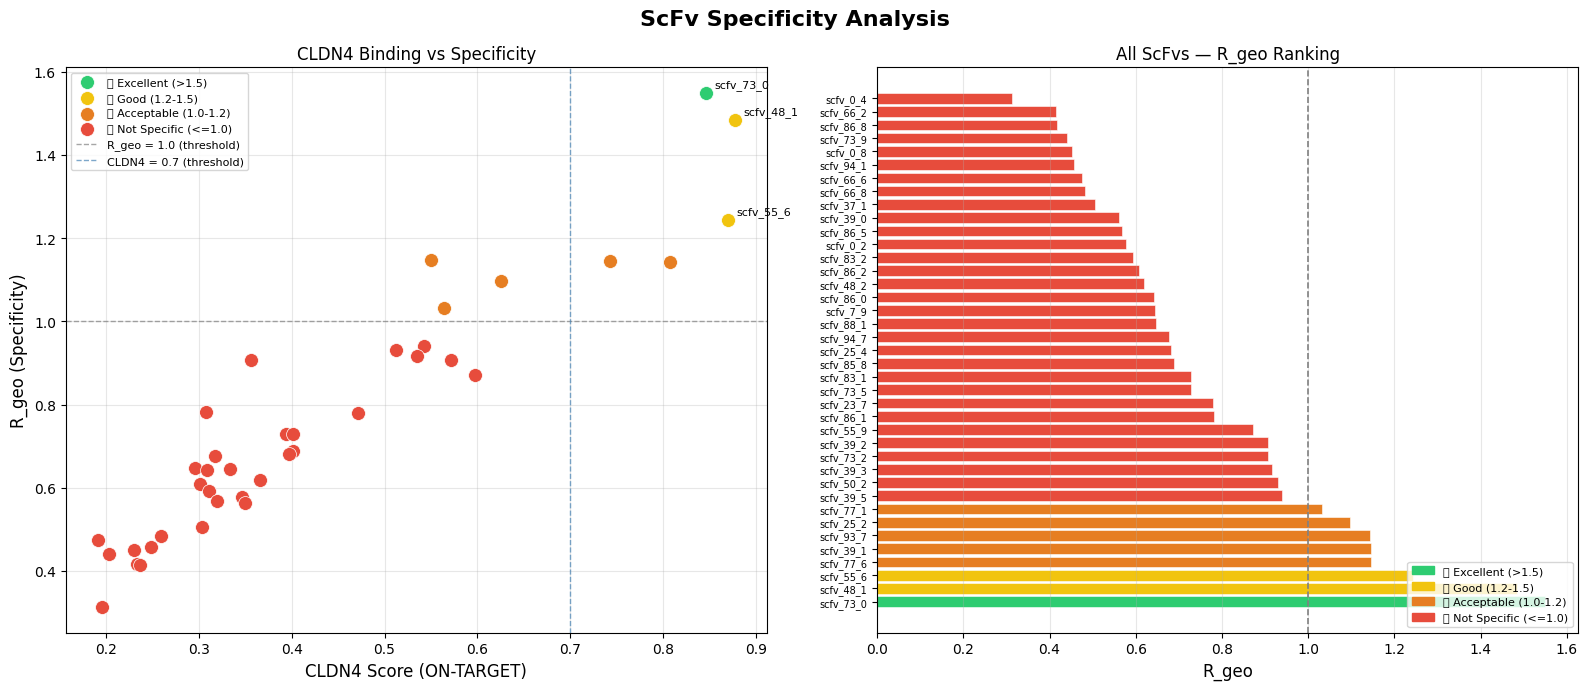

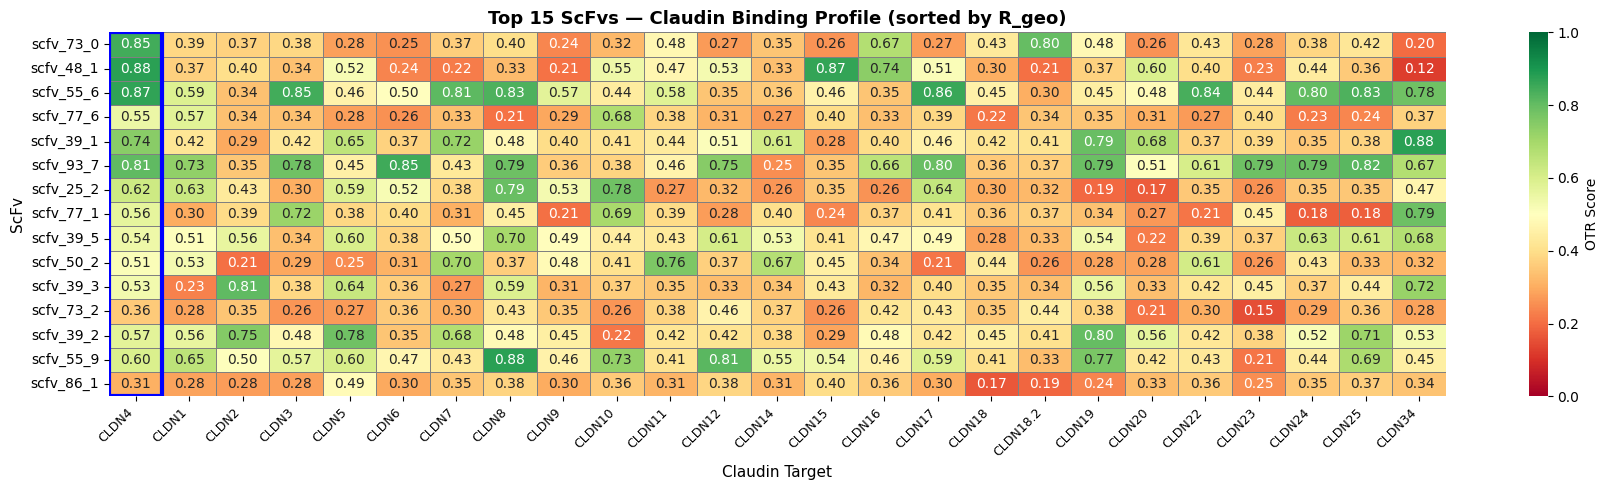

In [ ]:
# Specificity decision (Figure 2A)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- FILE PATH ---
INPUT_CSV = "/content/scfv_claudin_matrix_test1.csv"  # update this path

# --- LOAD DATA ---
df = pd.read_csv(INPUT_CSV, index_col=0)
off_cols = [c for c in df.columns if c != 'CLDN4']

# --- CALCULATE METRICS ---
results = []
for scfv in df.index:
    cldn4 = df.loc[scfv, 'CLDN4']
    off = df.loc[scfv, off_cols].dropna()
    avg_off = off.mean()
    max_off = off.max()
    max_off_name = off.idxmax()

    geo_denom = np.sqrt(avg_off * max_off)
    r_avg = cldn4 / avg_off     if avg_off   > 0 else 100
    r_max = cldn4 / max_off     if max_off   > 0 else 100
    r_geo = cldn4 / geo_denom   if geo_denom > 0 else 100

    results.append({
        'ScFv':           scfv,
        'CLDN4':          round(cldn4,    3),
        'Avg_Off':        round(avg_off,  3),
        'Max_Off':        round(max_off,  3),
        'Max_Off_Target': max_off_name,
        'R_avg':          round(r_avg,    3),
        'R_max':          round(r_max,    3),
        'R_geo':          round(r_geo,    3),
    })

res_df = pd.DataFrame(results).sort_values('R_geo', ascending=False)

# --- CATEGORIES ---
def categorize(r):
    if r > 1.5:  return '🟢 Excellent (>1.5)'
    if r > 1.2:  return '🟡 Good (1.2-1.5)'
    if r > 1.0:  return '🟠 Acceptable (1.0-1.2)'
    return              '🔴 Not Specific (<=1.0)'

res_df['Category'] = res_df['R_geo'].apply(categorize)

# ============================================================
# CONSOLE REPORT
# ============================================================
print("=" * 65)
print("  ScFv SPECIFICITY ANALYSIS  |  R_geo Metric")
print("=" * 65)

print("\n📊 OVERALL STATUS")
print(f"  Total ScFvs       : {len(res_df)}")
for cat in ['🟢 Excellent (>1.5)', '🟡 Good (1.2-1.5)',
            '🟠 Acceptable (1.0-1.2)', '🔴 Not Specific (<=1.0)']:
    n = len(res_df[res_df['Category'] == cat])
    print(f"  {cat:35s}: {n}")

print("\n🎯 CLDN4 BINDING STRENGTH")
print(f"  CLDN4 > 0.8 (Strong)    : {len(res_df[res_df['CLDN4'] > 0.8])}")
print(f"  CLDN4 0.6-0.8 (Moderate): {len(res_df[(res_df['CLDN4'] > 0.6) & (res_df['CLDN4'] <= 0.8)])}")
print(f"  CLDN4 < 0.6 (Weak)      : {len(res_df[res_df['CLDN4'] < 0.6])}")

print("\n⚠️  MOST DANGEROUS OFF-TARGETS (by Max_Off)")
print(res_df[['ScFv','CLDN4','Max_Off','Max_Off_Target','R_geo']]
      .sort_values('Max_Off', ascending=False)
      .head(5).to_string(index=False))

print("\n🌟 IDEAL CANDIDATES (CLDN4 > 0.7 AND R_geo > 1.2)")
ideal = res_df[(res_df['CLDN4'] > 0.7) & (res_df['R_geo'] > 1.2)]
if len(ideal):
    print(ideal[['ScFv','CLDN4','Avg_Off','Max_Off','Max_Off_Target','R_geo']].to_string(index=False))
else:
    print("  No candidates meet the criteria.")

print("\n📋 FULL RANKING (by R_geo)")
print(res_df[['ScFv','CLDN4','Avg_Off','Max_Off','Max_Off_Target',
              'R_avg','R_max','R_geo','Category']].to_string(index=False))

# ============================================================
# PLOT 1: Scatter — CLDN4 vs R_geo
# ============================================================
color_map = {
    '🟢 Excellent (>1.5)':       '#2ecc71',
    '🟡 Good (1.2-1.5)':         '#f1c40f',
    '🟠 Acceptable (1.0-1.2)':   '#e67e22',
    '🔴 Not Specific (<=1.0)':   '#e74c3c',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ScFv Specificity Analysis', fontsize=16, fontweight='bold')

# --- Left: Scatter CLDN4 vs R_geo ---
ax = axes[0]
for cat, color in color_map.items():
    subset = res_df[res_df['Category'] == cat]
    ax.scatter(subset['CLDN4'], subset['R_geo'],
               color=color, s=100, label=cat,
               edgecolors='white', linewidths=0.5, zorder=3)

# Label ideal candidates
for _, row in res_df[(res_df['CLDN4'] > 0.7) & (res_df['R_geo'] > 1.2)].iterrows():
    ax.annotate(row['ScFv'], (row['CLDN4'], row['R_geo']),
                textcoords='offset points', xytext=(6, 4), fontsize=8, color='black')

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='R_geo = 1.0 (threshold)')
ax.axvline(x=0.7, color='steelblue', linestyle='--', linewidth=1, alpha=0.7, label='CLDN4 = 0.7 (threshold)')
ax.set_xlabel('CLDN4 Score (ON-TARGET)', fontsize=12)
ax.set_ylabel('R_geo (Specificity)', fontsize=12)
ax.set_title('CLDN4 Binding vs Specificity', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

# --- Right: Horizontal bar chart by R_geo ---
ax2 = axes[1]
colors = [color_map[k] for k in res_df['Category']]
ax2.barh(res_df['ScFv'], res_df['R_geo'], color=colors, edgecolor='white', linewidth=0.4)
ax2.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xlabel('R_geo', fontsize=12)
ax2.set_title("All ScFvs — R_geo Ranking", fontsize=12)
ax2.tick_params(axis='y', labelsize=7)

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax2.legend(handles=patches, fontsize=8, loc='lower right')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('scfv_specificity_analysis.png', dpi=200, bbox_inches='tight')
print("\n✅ Plot saved: scfv_specificity_analysis.png")

# ============================================================
# PLOT 2: Heatmap — Top 15 ScFvs
# ============================================================
top15 = res_df.head(15)['ScFv'].tolist()
heatmap_data = df.loc[top15]

fig2, ax3 = plt.subplots(figsize=(18, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, linecolor='gray',
            cbar_kws={'label': 'OTR Score'}, ax=ax3)

if 'CLDN4' in heatmap_data.columns:
    cldn4_idx = heatmap_data.columns.get_loc('CLDN4')
    ax3.add_patch(plt.Rectangle((cldn4_idx, 0), 1, len(top15),
                                fill=False, edgecolor='blue', lw=3))

ax3.set_title("Top 15 ScFvs — Claudin Binding Profile (sorted by R_geo)",
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Claudin Target', fontsize=11)
ax3.set_ylabel('ScFv', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('scfv_top15_heatmap.png', dpi=200, bbox_inches='tight')
print("✅ Plot saved: scfv_top15_heatmap.png")

# --- Save results to CSV ---
res_df.to_csv('scfv_specificity_results.csv', index=False)
print("✅ Results saved: scfv_specificity_results.csv")

plt.show()


## Minor Corrections


  ScFv SPECIFICITY ANALYSIS  |  R_specificity Metric

📊 OVERALL STATUS
  Total ScFvs       : 39
  🟢 Excellent (>1.5)                 : 1
  🟡 Good (1.2-1.5)                   : 2
  🟠 Acceptable (1.0-1.2)             : 5
  🔴 Not Specific (<=1.0)             : 31

🎯 CLDN4 BINDING STRENGTH
  CLDN4 > 0.8 (Strong)    : 4
  CLDN4 0.6-0.8 (Moderate): 2
  CLDN4 < 0.6 (Weak)      : 33

⚠️  MOST DANGEROUS OFF-TARGETS (by Max_Off)
     ScFv  CLDN4  Max_Off Max_Off_Target  R_specificity
scfv_55_9  0.597    0.878          CLDN8          0.872
scfv_39_1  0.743    0.877         CLDN34          1.145
scfv_86_8  0.233    0.874         CLDN15          0.417
scfv_48_2  0.366    0.868         CLDN16          0.618
scfv_48_1  0.877    0.866         CLDN15          1.484

🌟 IDEAL CANDIDATES (CLDN4 > 0.7 AND R_specificity > 1.2)
     ScFv  CLDN4  Avg_Off  Max_Off Max_Off_Target  R_specificity
scfv_73_0  0.846    0.374    0.798       CLDN18.2          1.549
scfv_48_1  0.877    0.403    0.866         CLDN15    

/tmp/ipykernel_519/299680700.py:128: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/299680700.py:128: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/299680700.py:128: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/299680700.py:128: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_519/299680700.py:129: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('scfv_specificity_analysis.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_519/299680700.py:129: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('scfv_specificity_analysis.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_519/299680700.


✅ Plot saved: scfv_specificity_analysis.png
✅ Plot saved: scfv_specificity_analysis.pdf
✅ Results saved: scfv_specificity_results.csv


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


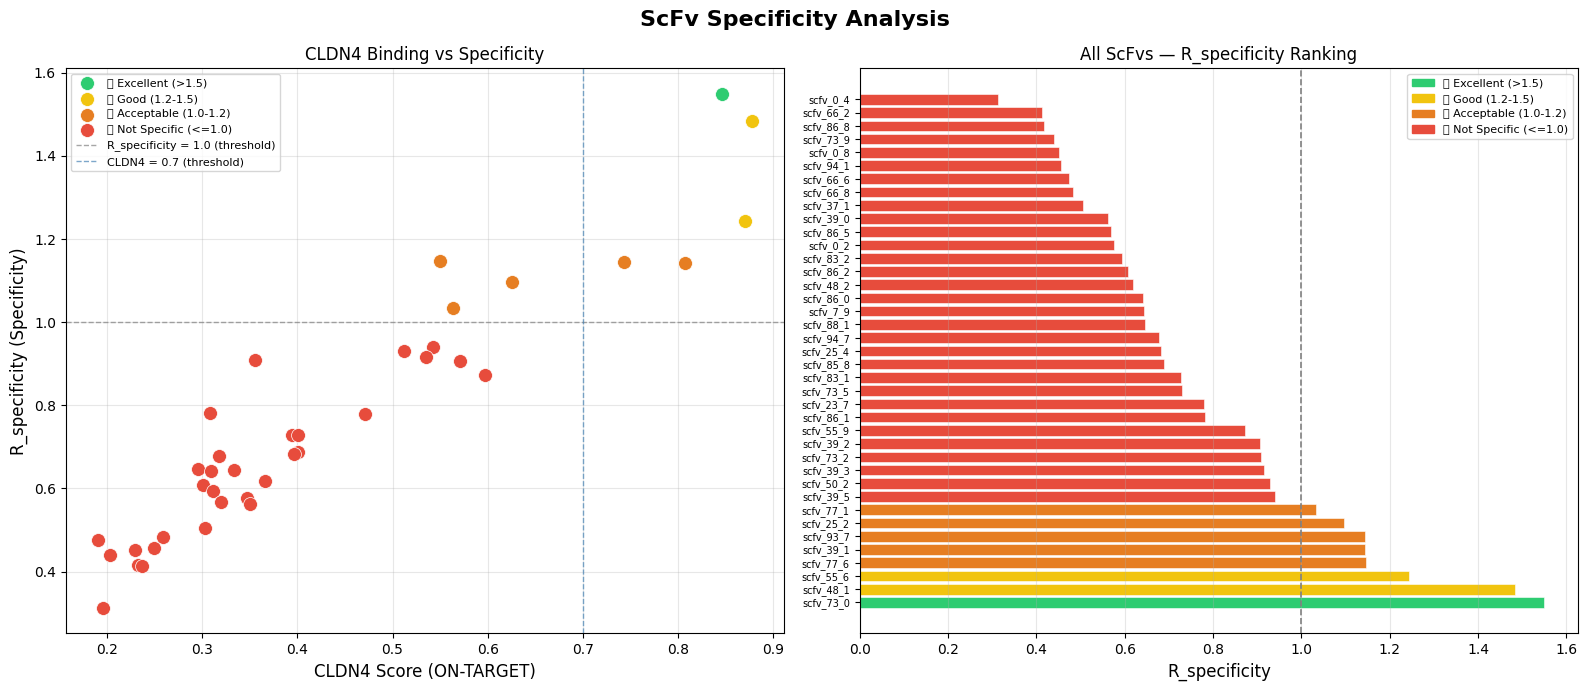

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- FILE PATH ---
INPUT_CSV = "scfv_claudin_matrix_test1.csv"  # update this path

# --- LOAD DATA ---
df = pd.read_csv(INPUT_CSV, index_col=0)
off_cols = [c for c in df.columns if c != 'CLDN4']

# --- CALCULATE METRICS ---
results = []
for scfv in df.index:
    cldn4 = df.loc[scfv, 'CLDN4']
    off = df.loc[scfv, off_cols].dropna()
    avg_off = off.mean()
    max_off = off.max()
    max_off_name = off.idxmax()

    spec_denom = np.sqrt(avg_off * max_off)
    r_avg = cldn4 / avg_off     if avg_off   > 0 else 100
    r_max = cldn4 / max_off     if max_off   > 0 else 100
    r_spec = cldn4 / spec_denom   if spec_denom > 0 else 100

    results.append({
        'ScFv':           scfv,
        'CLDN4':          round(cldn4,    3),
        'Avg_Off':        round(avg_off,  3),
        'Max_Off':        round(max_off,  3),
        'Max_Off_Target': max_off_name,
        'R_avg':          round(r_avg,    3),
        'R_max':          round(r_max,    3),
        'R_specificity':          round(r_spec,    3),
    })

res_df = pd.DataFrame(results).sort_values('R_specificity', ascending=False)

# --- CATEGORIES ---
def categorize(r):
    if r > 1.5:  return '🟢 Excellent (>1.5)'
    if r > 1.2:  return '🟡 Good (1.2-1.5)'
    if r > 1.0:  return '🟠 Acceptable (1.0-1.2)'
    return              '🔴 Not Specific (<=1.0)'

res_df['Category'] = res_df['R_specificity'].apply(categorize)

# ============================================================
# CONSOLE REPORT
# ============================================================
print("=" * 65)
print("  ScFv SPECIFICITY ANALYSIS  |  R_specificity Metric")
print("=" * 65)

print("\n📊 OVERALL STATUS")
print(f"  Total ScFvs       : {len(res_df)}")
for cat in ['🟢 Excellent (>1.5)', '🟡 Good (1.2-1.5)',
            '🟠 Acceptable (1.0-1.2)', '🔴 Not Specific (<=1.0)']:
    n = len(res_df[res_df['Category'] == cat])
    print(f"  {cat:35s}: {n}")

print("\n🎯 CLDN4 BINDING STRENGTH")
print(f"  CLDN4 > 0.8 (Strong)    : {len(res_df[res_df['CLDN4'] > 0.8])}")
print(f"  CLDN4 0.6-0.8 (Moderate): {len(res_df[(res_df['CLDN4'] > 0.6) & (res_df['CLDN4'] <= 0.8)])}")
print(f"  CLDN4 < 0.6 (Weak)      : {len(res_df[res_df['CLDN4'] < 0.6])}")

print("\n⚠️  MOST DANGEROUS OFF-TARGETS (by Max_Off)")
print(res_df[['ScFv','CLDN4','Max_Off','Max_Off_Target','R_specificity']]
      .sort_values('Max_Off', ascending=False)
      .head(5).to_string(index=False))

print("\n🌟 IDEAL CANDIDATES (CLDN4 > 0.7 AND R_specificity > 1.2)")
ideal = res_df[(res_df['CLDN4'] > 0.7) & (res_df['R_specificity'] > 1.2)]
if len(ideal):
    print(ideal[['ScFv','CLDN4','Avg_Off','Max_Off','Max_Off_Target','R_specificity']].to_string(index=False))
else:
    print("  No candidates meet the criteria.")

print("\n📋 FULL RANKING (by R_specificity)")
print(res_df[['ScFv','CLDN4','Avg_Off','Max_Off','Max_Off_Target',
              'R_avg','R_max','R_specificity','Category']].to_string(index=False))

# ============================================================
# PLOT 1: Scatter — CLDN4 vs R_specificity
# ============================================================
color_map = {
    '🟢 Excellent (>1.5)':       '#2ecc71',
    '🟡 Good (1.2-1.5)':         '#f1c40f',
    '🟠 Acceptable (1.0-1.2)':   '#e67e22',
    '🔴 Not Specific (<=1.0)':   '#e74c3c',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ScFv Specificity Analysis', fontsize=16, fontweight='bold')

# --- Left: Scatter CLDN4 vs R_specificity ---
ax = axes[0]
for cat, color in color_map.items():
    subset = res_df[res_df['Category'] == cat]
    ax.scatter(subset['CLDN4'], subset['R_specificity'],
               color=color, s=100, label=cat,
               edgecolors='white', linewidths=0.5, zorder=3)


ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='R_specificity = 1.0 (threshold)')
ax.axvline(x=0.7, color='steelblue', linestyle='--', linewidth=1, alpha=0.7, label='CLDN4 = 0.7 (threshold)')
ax.set_xlabel('CLDN4 Score (ON-TARGET)', fontsize=12)
ax.set_ylabel('R_specificity (Specificity)', fontsize=12)
ax.set_title('CLDN4 Binding vs Specificity', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

# --- Right: Horizontal bar chart by R_specificity ---
ax2 = axes[1]
colors = [color_map[k] for k in res_df['Category']]
ax2.barh(res_df['ScFv'], res_df['R_specificity'], color=colors, edgecolor='white', linewidth=0.4)
ax2.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.2)
ax2.set_xlabel('R_specificity', fontsize=12)
ax2.set_title("All ScFvs — R_specificity Ranking", fontsize=12)
ax2.tick_params(axis='y', labelsize=7)

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax2.legend(handles=patches, fontsize=8, loc='upper right')
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('scfv_specificity_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('scfv_specificity_analysis.pdf', dpi=300, bbox_inches='tight')
print("\n✅ Plot saved: scfv_specificity_analysis.png")
print("✅ Plot saved: scfv_specificity_analysis.pdf")
# --- Save results to CSV ---
res_df.to_csv('scfv_specificity_results.csv', index=False)
print("✅ Results saved: scfv_specificity_results.csv")

plt.show()